<a href="https://colab.research.google.com/github/wolfgangmoon/Satelite/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")

sns.set(style='whitegrid')
df=pd.read_csv('https://raw.githubusercontent.com/wolfgangmoon/Satelite/refs/heads/main/NYPD_Arrests_Data_(Historic)_20251210%20(1).csv')
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace('[^0-9a-zA-Z_]+', '', regex=True))
df.head()


,arrest_key,arrest_date,pd_desc,law_cat_cd,arrest_boro,arrest_precinct,age_group,perp_sex,perp_race
0,298694785,12/31/2024,"FORGERY,ETC.,UNCLASSIFIED-FELO",F,K,73,25-44,M,BLACK
1,298690461,12/31/2024,"ROBBERY,OPEN AREA UNCLASSIFIED",F,K,77,25-44,M,BLACK
2,298692614,12/31/2024,"THEFT OF SERVICES, UNCLASSIFIE",M,K,77,25-44,M,BLACK
3,298678556,12/31/2024,ASSAULT 3,M,K,77,18-24,M,BLACK
4,298700791,12/31/2024,"PUBLIC ADMINISTRATION,UNCLASSI",F,K,73,25-44,F,BLACK


/tmp/ipython-input-3086451941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Arrest_Precinct', y='Total_Arrests', data=arrests_by_precinct, palette='viridis',)


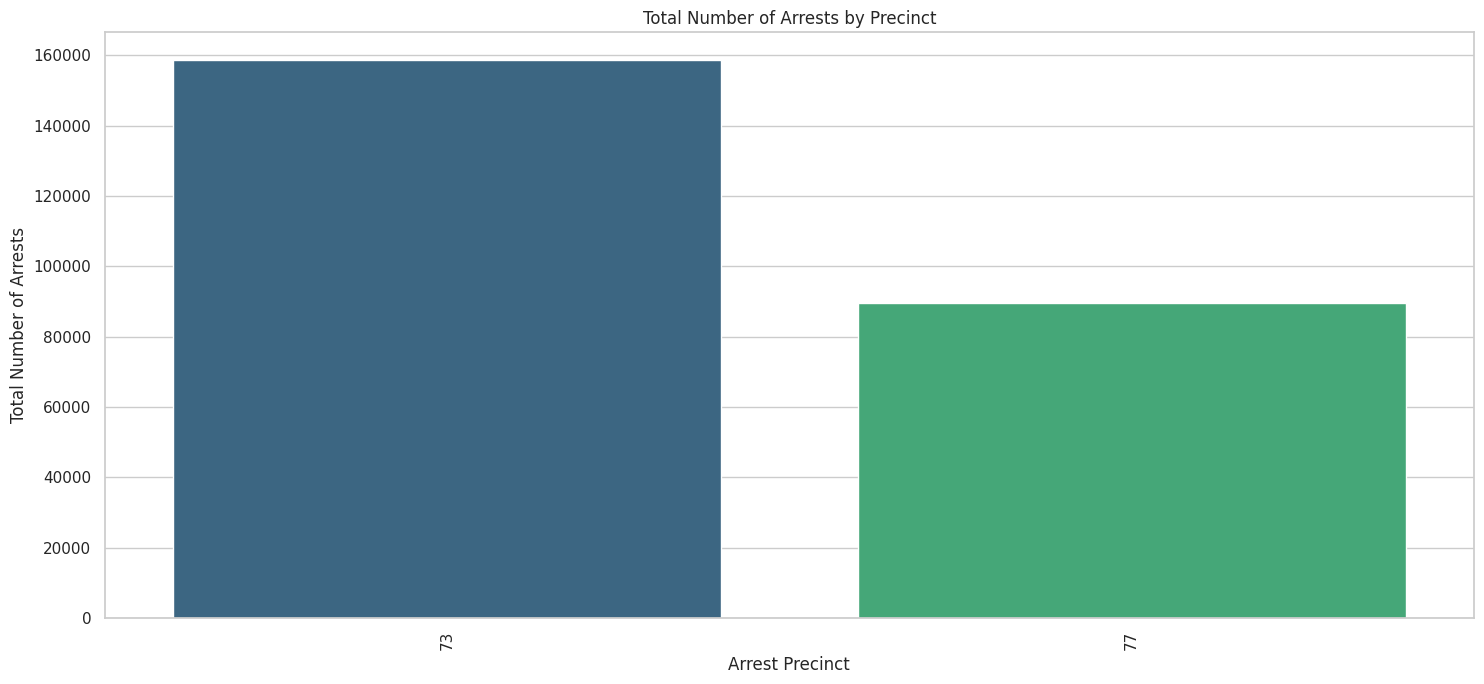

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

arrests_by_precinct = df['arrest_precinct'].value_counts().reset_index()
arrests_by_precinct.columns = ['Arrest_Precinct', 'Total_Arrests']

plt.figure(figsize=(15, 7))
sns.barplot(x='Arrest_Precinct', y='Total_Arrests', data=arrests_by_precinct, palette='viridis',)
plt.xlabel('Arrest Precinct')
plt.ylabel('Total Number of Arrests')
plt.title('Total Number of Arrests by Precinct')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
df['arrest_date'] = pd.to_datetime(df['arrest_date'])
df['arrest_month'] = df['arrest_date'].dt.month
df['arrest_year'] = df['arrest_date'].dt.year
df.head()

,arrest_key,arrest_date,pd_desc,law_cat_cd,arrest_boro,arrest_precinct,age_group,perp_sex,perp_race,arrest_month,arrest_year
0,298694785,2024-12-31,"FORGERY,ETC.,UNCLASSIFIED-FELO",F,K,73,25-44,M,BLACK,12,2024
1,298690461,2024-12-31,"ROBBERY,OPEN AREA UNCLASSIFIED",F,K,77,25-44,M,BLACK,12,2024
2,298692614,2024-12-31,"THEFT OF SERVICES, UNCLASSIFIE",M,K,77,25-44,M,BLACK,12,2024
3,298678556,2024-12-31,ASSAULT 3,M,K,77,18-24,M,BLACK,12,2024
4,298700791,2024-12-31,"PUBLIC ADMINISTRATION,UNCLASSI",F,K,73,25-44,F,BLACK,12,2024


In [ ]:
filtered_df = df[df['arrest_precinct'].isin([73, 77])]
print("Filtered DataFrame head:")
print(filtered_df.head())

Filtered DataFrame head:
   arrest_key arrest_date                         pd_desc law_cat_cd  \
0   298694785  2024-12-31  FORGERY,ETC.,UNCLASSIFIED-FELO          F   
1   298690461  2024-12-31  ROBBERY,OPEN AREA UNCLASSIFIED          F   
2   298692614  2024-12-31  THEFT OF SERVICES, UNCLASSIFIE          M   
3   298678556  2024-12-31                       ASSAULT 3          M   
4   298700791  2024-12-31  PUBLIC ADMINISTRATION,UNCLASSI          F   

  arrest_boro  arrest_precinct age_group perp_sex perp_race  arrest_month  \
0           K               73     25-44        M     BLACK            12   
1           K               77     25-44        M     BLACK            12   
2           K               77     25-44        M     BLACK            12   
3           K               77     18-24        M     BLACK            12   
4           K               73     25-44        F     BLACK            12   

   arrest_year  
0         2024  
1         2024  
2         2024  
3         2

In [ ]:
arrests_over_time = filtered_df.groupby(['arrest_date', 'arrest_precinct']).size().reset_index(name='number_of_arrests')
print("Arrests over time head:")
print(arrests_over_time.head())

Arrests over time head:
  arrest_date  arrest_precinct  number_of_arrests
0  2006-01-01               73                 20
1  2006-01-01               77                  9
2  2006-01-02               73                 16
3  2006-01-02               77                 11
4  2006-01-03               73                 14


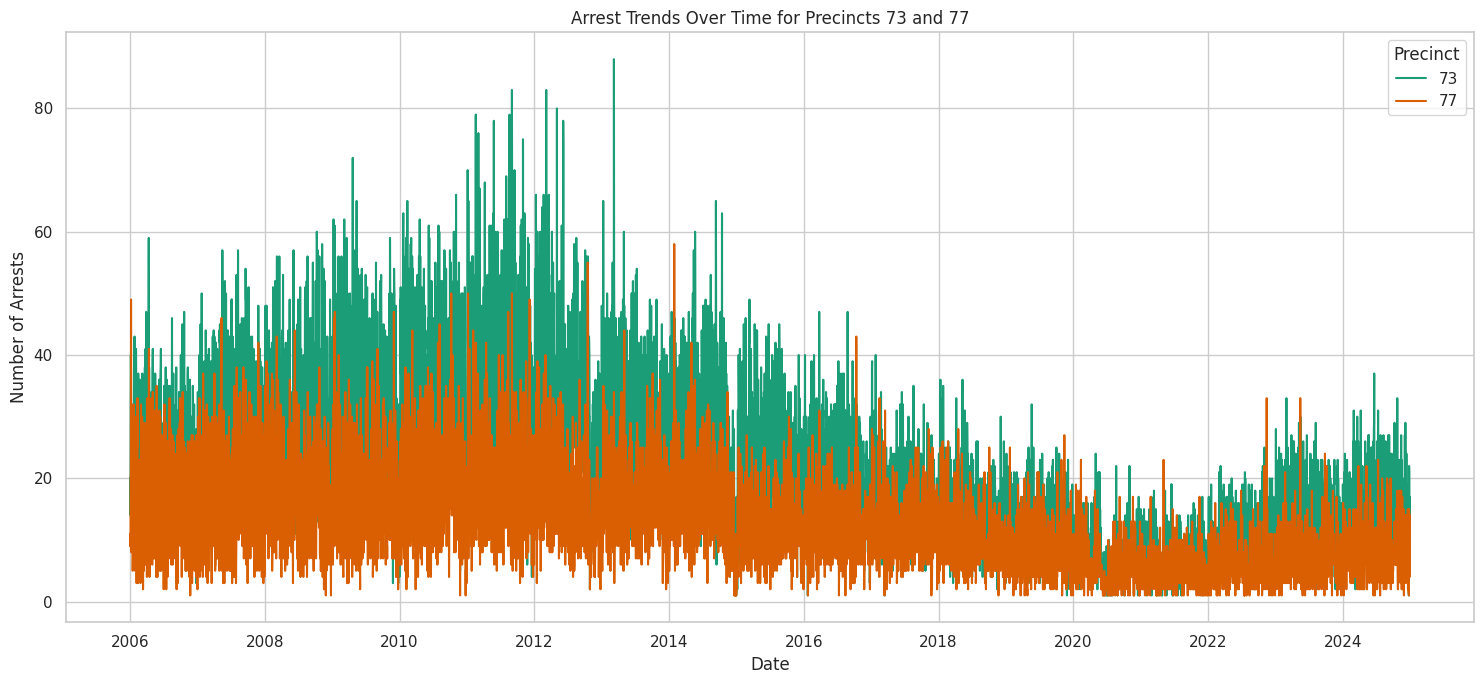

In [ ]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=arrests_over_time, x='arrest_date', y='number_of_arrests', hue='arrest_precinct', palette='Dark2')
plt.xlabel('Date')
plt.ylabel('Number of Arrests')
plt.title('Arrest Trends Over Time for Precincts 73 and 77')
plt.legend(title='Precinct')
plt.tight_layout()
plt.show()

In [ ]:

felony_df = df[df['law_cat_cd'] == 'F']

felonies_by_precinct = felony_df['arrest_precinct'].value_counts().reset_index()
felonies_by_precinct.columns = ['Arrest_Precinct', 'Total_Felonies']

print("Total Felonies by Precinct")
display(felonies_by_precinct.head(10))

Total Felonies by Precinct


,Arrest_Precinct,Total_Felonies
0,73,44846
1,77,32403


/tmp/ipython-input-3436522952.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Arrest_Precinct', y='Total_Felonies', data=felonies_by_precinct, palette='plasma')


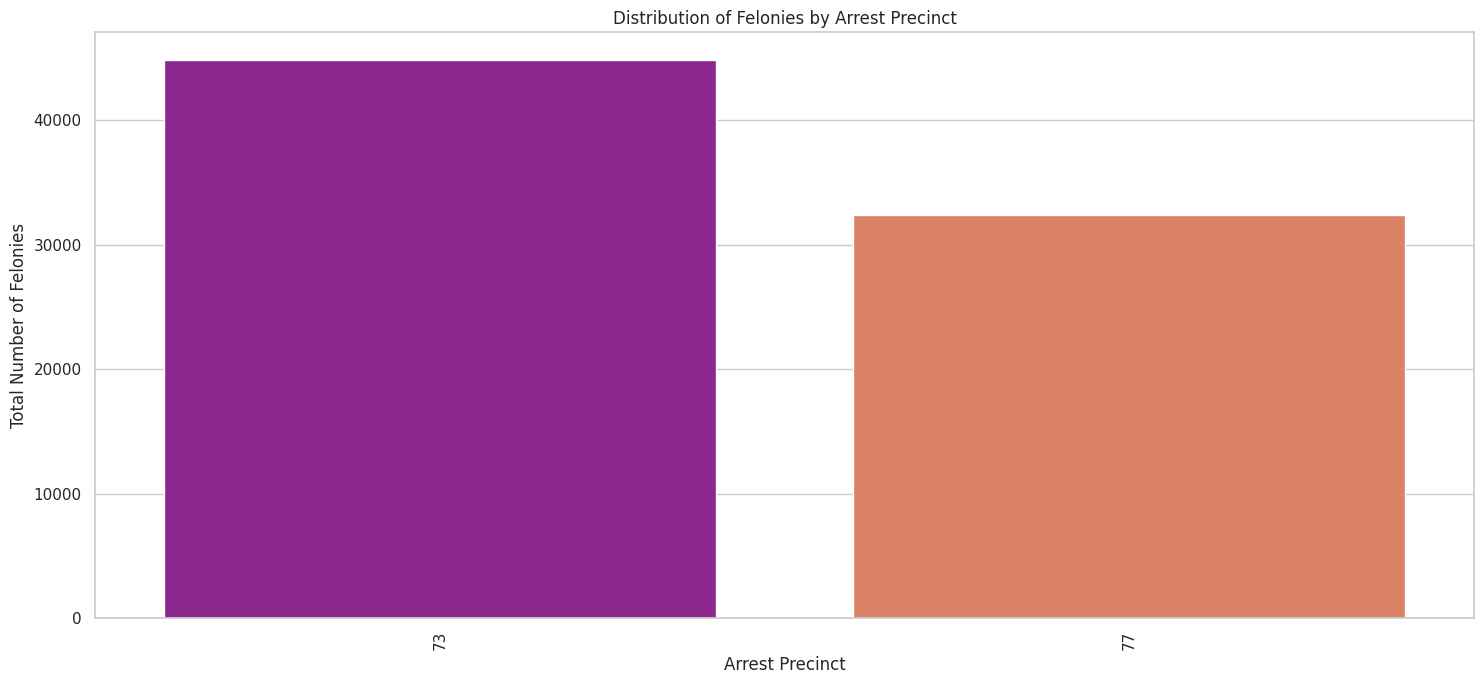

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x='Arrest_Precinct', y='Total_Felonies', data=felonies_by_precinct, palette='plasma')
plt.xlabel('Arrest Precinct')
plt.ylabel('Total Number of Felonies')
plt.title('Distribution of Felonies by Arrest Precinct')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:

total_arrests_by_precinct = df['arrest_precinct'].value_counts().reset_index()
total_arrests_by_precinct.columns = ['Arrest_Precinct', 'Total_Arrests']

felony_percentage_df['Percentage_Felonies'] = (felony_percentage_df['Total_Felonies'] / felony_percentage_df['Total_Arrests']) * 100

felony_percentage_df = felony_percentage_df.sort_values(by='Percentage_Felonies', ascending=False).reset_index(drop=True)

print("Top 10 Precincts by Percentage of Felonies:")
display(felony_percentage_df.head(10))

Top 10 Precincts by Percentage of Felonies:


,Arrest_Precinct,Total_Felonies,Total_Arrests,Percentage_Felonies
0,77,32403,89494,36.21
1,73,44846,158637,28.27


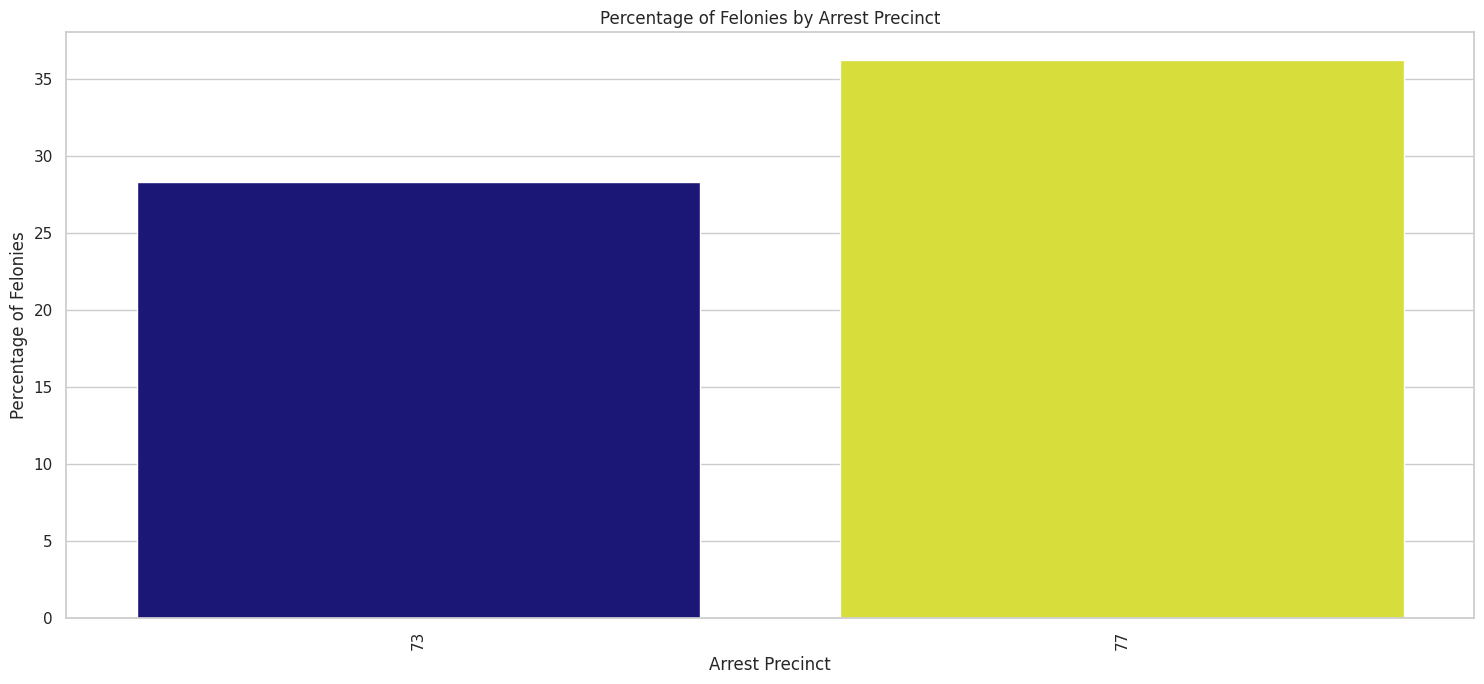

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x='Arrest_Precinct', y='Percentage_Felonies', data=felony_percentage_df, hue='Arrest_Precinct', palette='plasma', legend=False)
plt.xlabel('Arrest Precinct')
plt.ylabel('Percentage of Felonies')
plt.title('Percentage of Felonies by Arrest Precinct')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Bias is a constant concern in policing especially in regards to enforcement and police presence. It is hard to come to any definitive conclusions without additional sources of data or rigorous analysis that controls for varios other factors.